Import Libraries

In [1]:
# Importing essential libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

Loading and Preprcessing the data

In [2]:
# Load the dataset
df = pd.read_csv("../Data/disease_diagnosis.csv")

In [3]:
print("\n================ Dataset Info ================\n")
print(df.info())

print("\n================ Missing Values ================\n")
print(df.isna().sum())

print("\n================ Summary Statistics ================\n")
print(df.describe())

print("\n================ Top Diagnoses (10) ================\n")
print(df["Diagnosis"].value_counts().head(10))


================ Dataset Info ================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           2000 non-null   int64  
 1   Age                  2000 non-null   int64  
 2   Gender               2000 non-null   object 
 3   Symptom_1            2000 non-null   object 
 4   Symptom_2            2000 non-null   object 
 5   Symptom_3            2000 non-null   object 
 6   Heart_Rate_bpm       2000 non-null   int64  
 7   Body_Temperature_C   2000 non-null   float64
 8   Blood_Pressure_mmHg  2000 non-null   object 
 9   Oxygen_Saturation_%  2000 non-null   int64  
 10  Diagnosis            2000 non-null   object 
 11  Severity             2000 non-null   object 
 12  Treatment_Plan       2000 non-null   object 
dtypes: float64(1), int64(4), object(8)
memory usage: 203.2+ KB
None

================ Missing

In [4]:
# Drop Patient_ID as it's not a feature for the model
df.drop('Patient_ID', axis=1, inplace=True)

# Split Blood_Pressure_mmHg into Systolic and Diastolic
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood_Pressure_mmHg'].str.split('/', expand=True)

# Convert the new BP columns to numeric type
df['Systolic_BP'] = pd.to_numeric(df['Systolic_BP'])
df['Diastolic_BP'] = pd.to_numeric(df['Diastolic_BP'])

# Drop the original blood pressure column
df.drop('Blood_Pressure_mmHg', axis=1, inplace=True)

print("\nData after cleaning and feature extraction:")
display(df.head())


Data after cleaning and feature extraction:


,Age,Gender,Symptom_1,Symptom_2,Symptom_3,Heart_Rate_bpm,Body_Temperature_C,Oxygen_Saturation_%,Diagnosis,Severity,Treatment_Plan,Systolic_BP,Diastolic_BP
0,74,Male,Fatigue,Sore throat,Fever,69,39.4,94,Flu,Moderate,Medication and rest,132,91
1,66,Female,Sore throat,Fatigue,Cough,95,39.0,98,Healthy,Mild,Rest and fluids,174,98
2,32,Male,Body ache,Sore throat,Fatigue,77,36.8,96,Healthy,Mild,Rest and fluids,136,60
3,21,Female,Shortness of breath,Headache,Cough,72,38.9,99,Healthy,Mild,Rest and fluids,147,82
4,53,Male,Runny nose,Sore throat,Fatigue,100,36.6,92,Healthy,Mild,Rest and fluids,109,106



Distribution of Numerical Features:


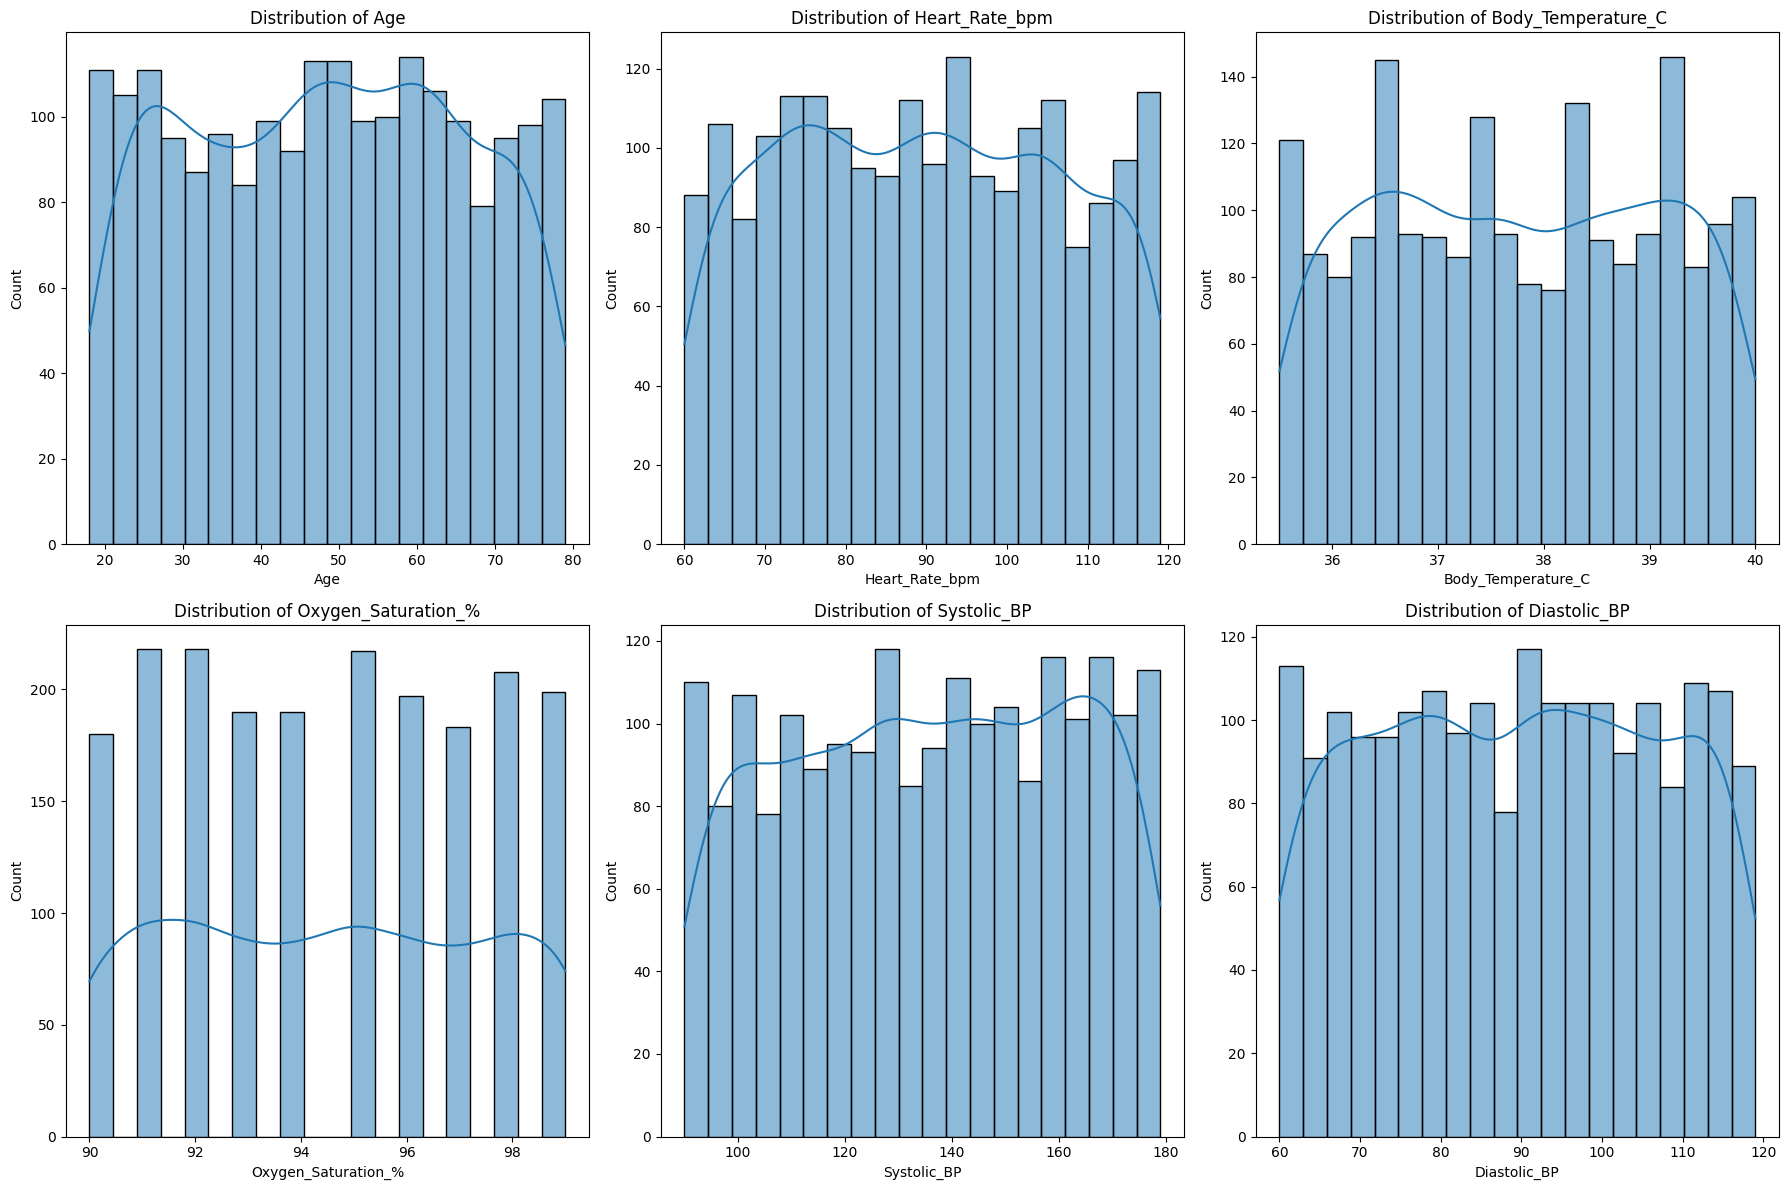


Distribution of Categorical Features:


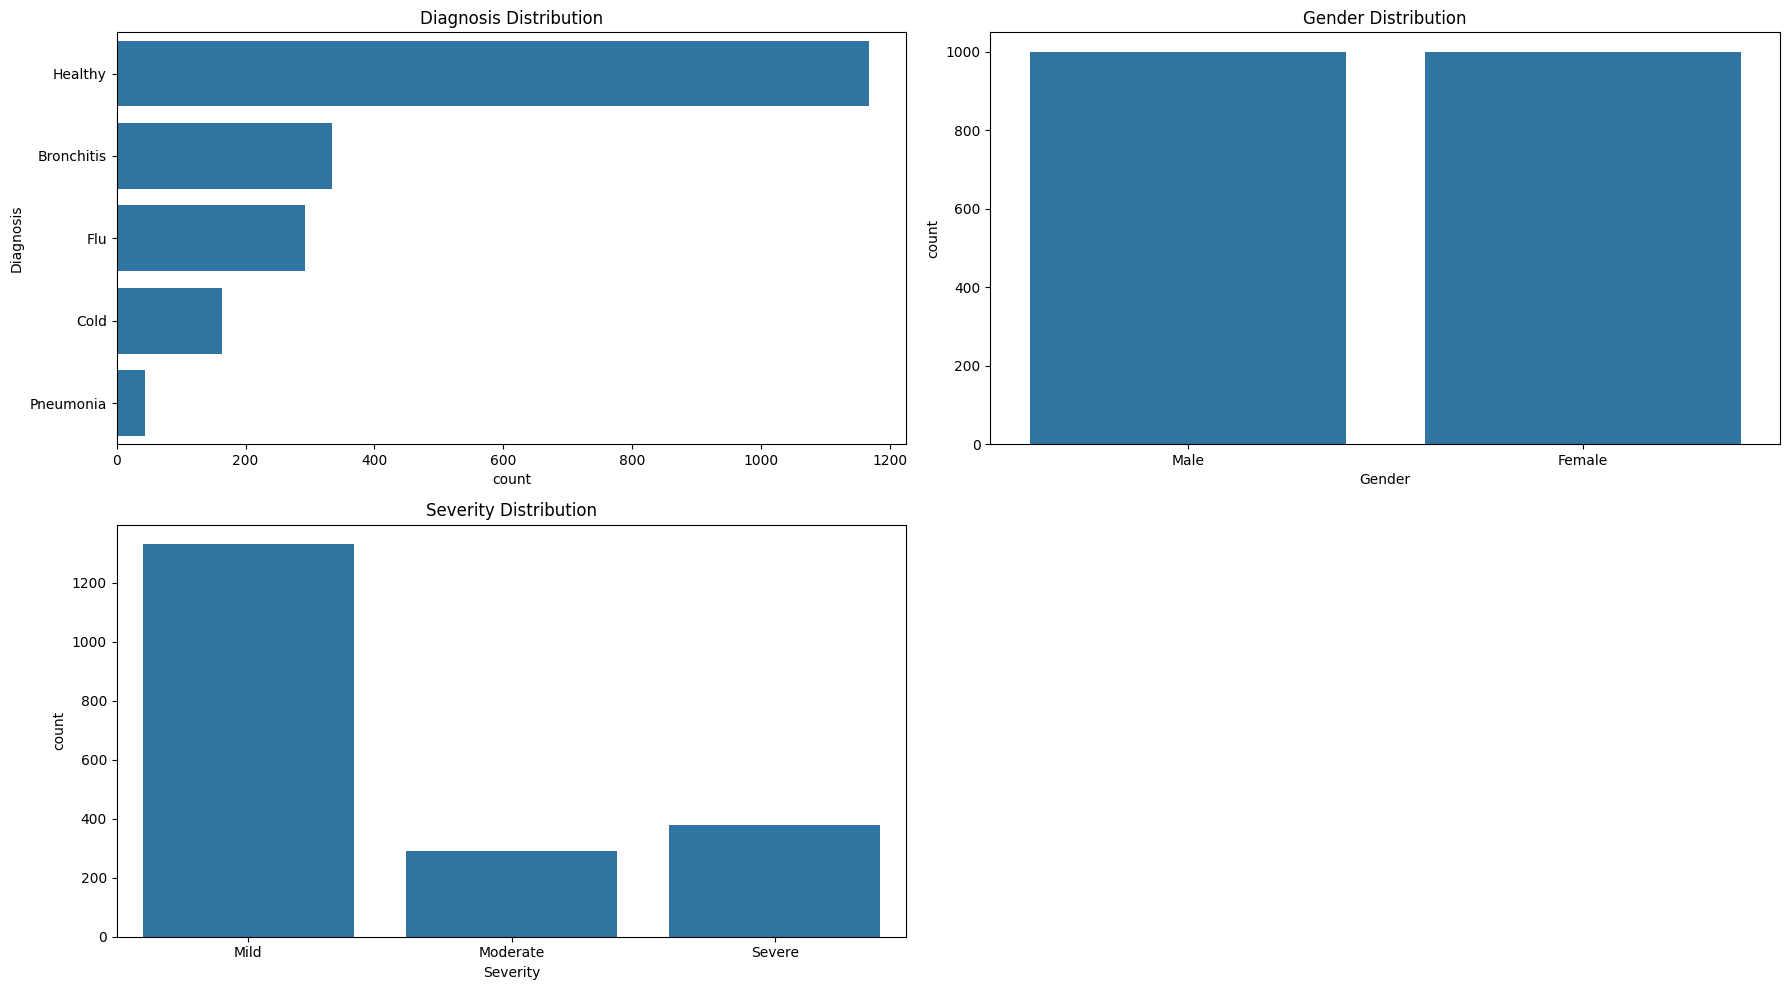

In [5]:
# Define numerical and categorical features
numerical_features = ['Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%', 'Systolic_BP', 'Diastolic_BP']
categorical_features = ['Gender', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Diagnosis', 'Severity', 'Treatment_Plan']

# Plot distributions for numerical features
print("\nDistribution of Numerical Features:")
plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Plot counts for key categorical features
print("\nDistribution of Categorical Features:")
plt.figure(figsize=(18, 10))
# Diagnosis
plt.subplot(2, 2, 1)
sns.countplot(y=df['Diagnosis'], order=df['Diagnosis'].value_counts().index)
plt.title('Diagnosis Distribution')
# Gender
plt.subplot(2, 2, 2)
sns.countplot(x=df['Gender'])
plt.title('Gender Distribution')
# Severity
plt.subplot(2, 2, 3)
sns.countplot(x=df['Severity'], order=['Mild', 'Moderate', 'Severe'])
plt.title('Severity Distribution')
plt.tight_layout()
plt.show()

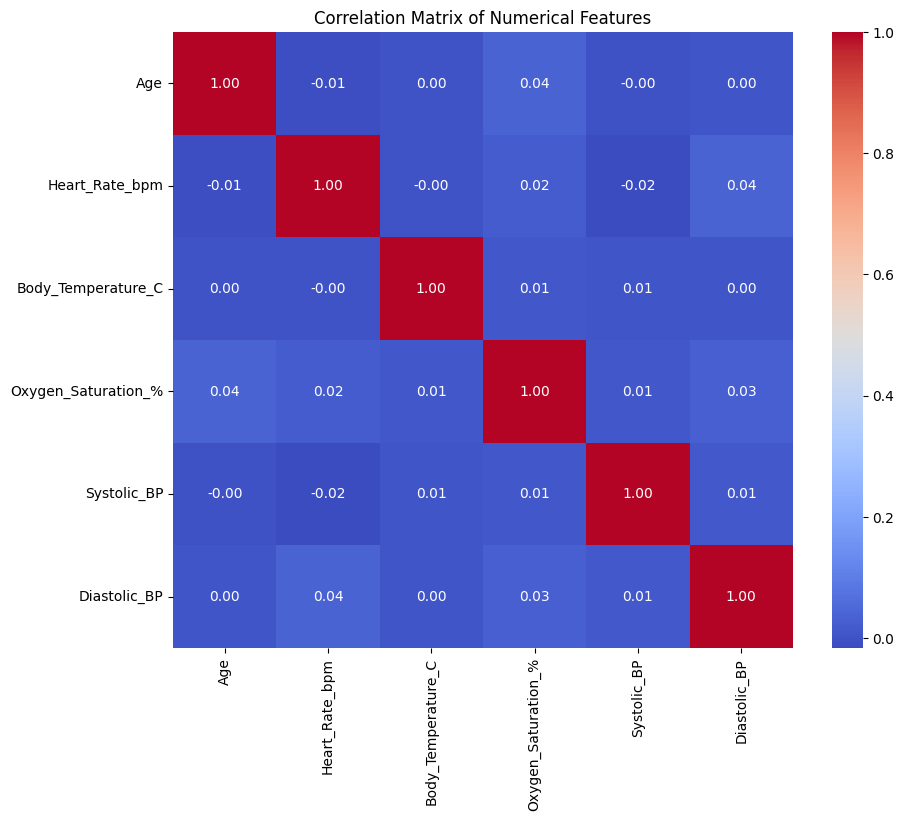

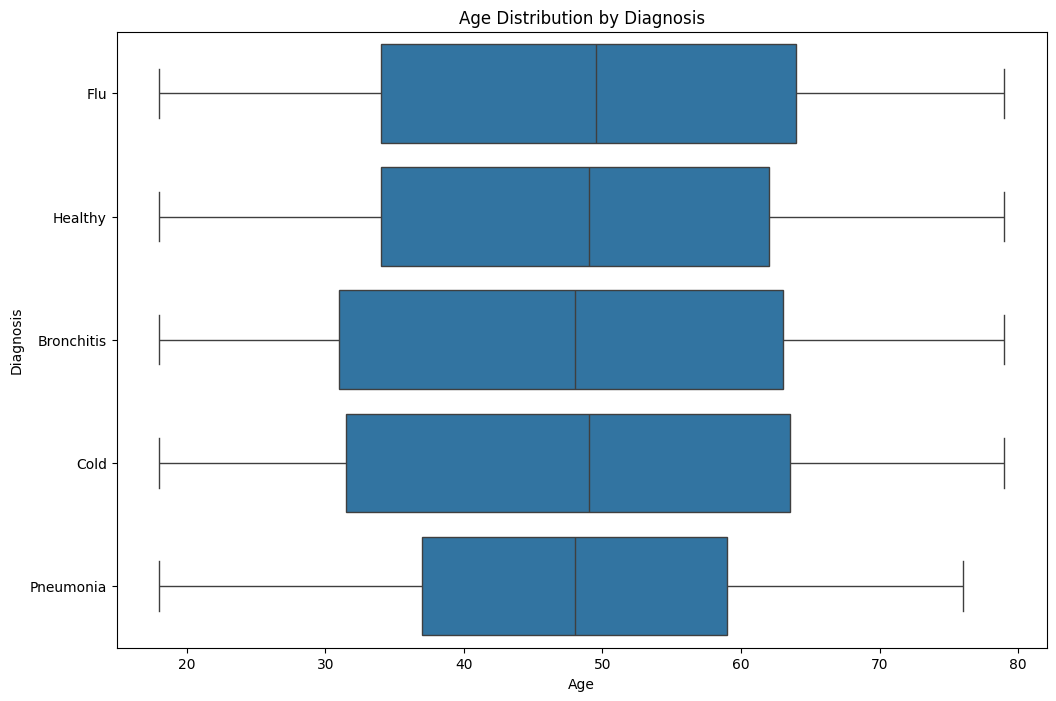

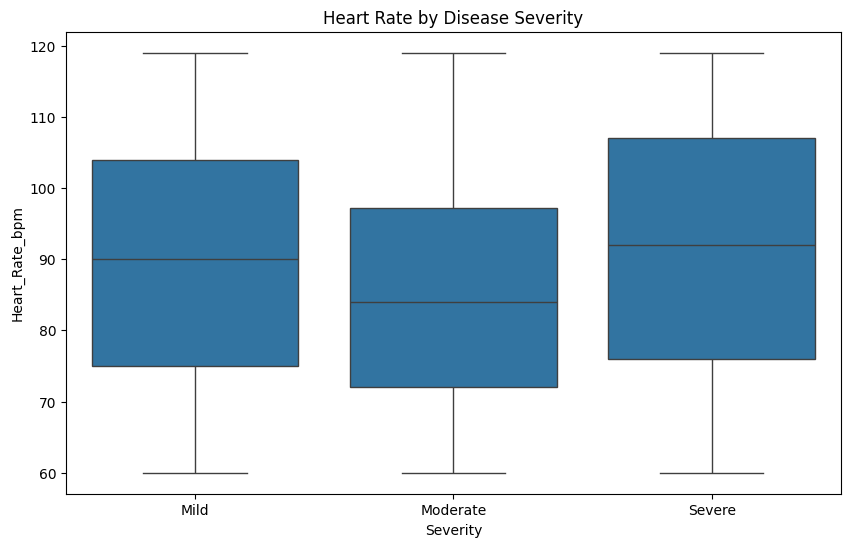

In [6]:
# Correlation heatmap for numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Age vs. Diagnosis
plt.figure(figsize=(12, 8))
sns.boxplot(x='Age', y='Diagnosis', data=df)
plt.title('Age Distribution by Diagnosis')
plt.show()

# Heart Rate vs. Severity
plt.figure(figsize=(10, 6))
sns.boxplot(x='Severity', y='Heart_Rate_bpm', data=df, order=['Mild', 'Moderate', 'Severe'])
plt.title('Heart Rate by Disease Severity')
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features (X) and target (y)
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

# The 'Severity' column is ordinal, so we'll map it manually.
severity_mapping = {'Mild': 0, 'Moderate': 1, 'Severe': 2}
X['Severity'] = X['Severity'].map(severity_mapping)

# Identify feature types for preprocessing
# We will one-hot encode nominal categorical features and scale numerical ones.
# We've already handled 'Severity'.
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = ['Gender', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Treatment_Plan']

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a preprocessor object using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough' # Keep other columns (if any)
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (1600, 12)
Testing set shape: (400, 12)



Training the RandomForestClassifier...
Training complete!

Model Accuracy: 0.9950

Classification Report:
              precision    recall  f1-score   support

  Bronchitis       0.97      1.00      0.99        67
        Cold       1.00      1.00      1.00        33
         Flu       1.00      1.00      1.00        58
     Healthy       1.00      1.00      1.00       233
   Pneumonia       1.00      0.78      0.88         9

    accuracy                           0.99       400
   macro avg       0.99      0.96      0.97       400
weighted avg       1.00      0.99      0.99       400


Confusion Matrix:


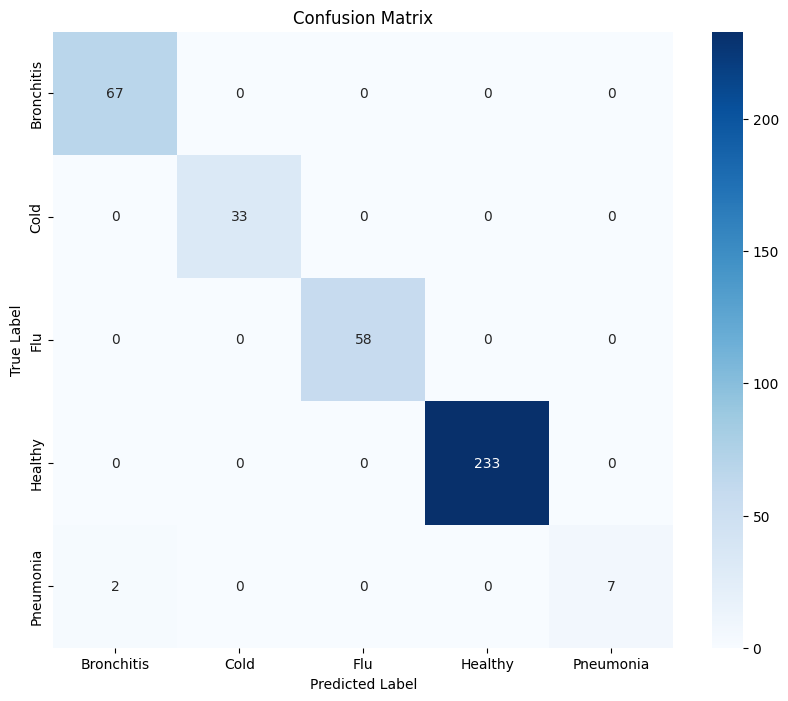

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Define the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Create the full pipeline by combining the preprocessor and the model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

# Train the model
print("\nTraining the RandomForestClassifier...")
model_pipeline.fit(X_train, y_train)
print("Training complete!")

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")

# Display the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display the confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Updated

Initial Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           2000 non-null   int64  
 1   Age                  2000 non-null   int64  
 2   Gender               2000 non-null   object 
 3   Symptom_1            2000 non-null   object 
 4   Symptom_2            2000 non-null   object 
 5   Symptom_3            2000 non-null   object 
 6   Heart_Rate_bpm       2000 non-null   int64  
 7   Body_Temperature_C   2000 non-null   float64
 8   Blood_Pressure_mmHg  2000 non-null   object 
 9   Oxygen_Saturation_%  2000 non-null   int64  
 10  Diagnosis            2000 non-null   object 
 11  Severity             2000 non-null   object 
 12  Treatment_Plan       2000 non-null   object 
dtypes: float64(1), int64(4), object(8)
memory usage: 203.2+ KB
None


Training set shape: (1600, 10)
Testing set shape: 

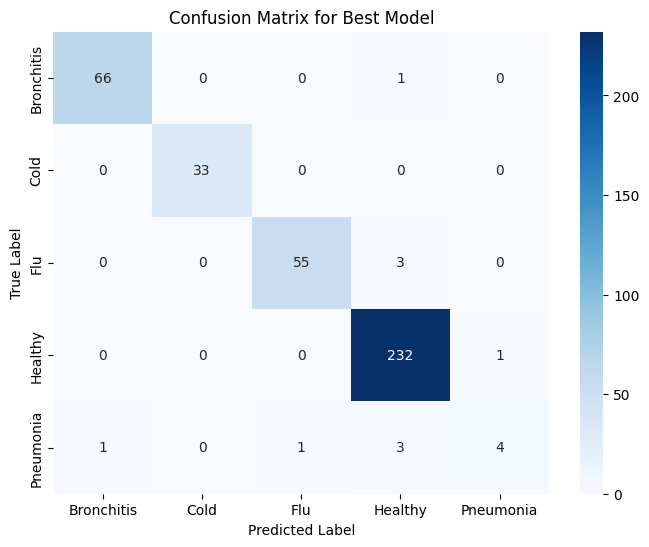

In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

# --- 1. Data Loading and Feature Engineering ---
# Load the dataset
try:
    # df = pd.read_csv("disease_diagnosis.csv")
    df = pd.read_csv("../Data/disease_diagnosis.csv")
except FileNotFoundError:
    print("Error: 'disease_diagnosis.csv' not found. Please ensure it is in the same directory.")
    exit()

print("Initial Dataset Info:")
print(df.info())
print("\n" + "="*50 + "\n")

# Drop 'Patient_ID' and non-predictive output columns
df.drop(['Patient_ID', 'Severity', 'Treatment_Plan'], axis=1, inplace=True)

# Split 'Blood_Pressure_mmHg'
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood_Pressure_mmHg'].str.split('/', expand=True)
df['Systolic_BP'] = pd.to_numeric(df['Systolic_BP'])
df['Diastolic_BP'] = pd.to_numeric(df['Diastolic_BP'])
df.drop('Blood_Pressure_mmHg', axis=1, inplace=True)

# --- 2. Preprocessing & Data Splitting ---
# Define features (X) and the single target (y)
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

# Define feature types for preprocessing
numerical_features = ['Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%', 'Systolic_BP', 'Diastolic_BP']
nominal_categorical_features = ['Gender', 'Symptom_1', 'Symptom_2', 'Symptom_3']

# Create the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_categorical_features)
    ],
    remainder='passthrough'
)

# Split data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print("\n" + "="*50 + "\n")

# --- 3. Model Training with Class Imbalance Handling ---
# Use LabelEncoder to convert string labels to numbers
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
class_labels = list(le.classes_)

# Define models and their hyperparameters, including class_weight
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear', max_iter=1000),
}

params = {
    "Random Forest": {
        'classifier__n_estimators': [50, 100],
        'classifier__max_depth': [10, None],
        'classifier__class_weight': ['balanced', None]
    },
    "Logistic Regression": {
        'classifier__C': [0.1, 1.0],
        'classifier__class_weight': ['balanced', None]
    }
}

best_model = None
best_score = 0
model_report = {}

for name, model in models.items():
    print(f"--- Training {name} with GridSearchCV ---")
    
    # Create the full pipeline including the preprocessor and the model
    model_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    
    # Use GridSearchCV to find the best hyperparameters
    gs = GridSearchCV(model_pipeline, params[name], cv=3, scoring='f1_weighted', verbose=1)
    gs.fit(X_train, y_train)
    
    current_best_model = gs.best_estimator_
    
    y_pred = current_best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    model_report[name] = accuracy
    
    if accuracy > best_score:
        best_score = accuracy
        best_model = current_best_model

print("\n" + "="*50 + "\n")
print("Model Training Report:")
for name, acc in model_report.items():
    print(f"  - {name}: {acc:.4f}")

print(f"\nBest Model: {best_model.named_steps['classifier'].__class__.__name__} with Accuracy: {best_score:.4f}")
print("\n" + "="*50 + "\n")

# --- 4. Final Evaluation of the Best Model ---
print("Final Evaluation of the Best Model:")
y_pred = best_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_labels))

# --- 5. Visualization ---
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for Best Model')
plt.show()

smote

Initial Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           2000 non-null   int64  
 1   Age                  2000 non-null   int64  
 2   Gender               2000 non-null   object 
 3   Symptom_1            2000 non-null   object 
 4   Symptom_2            2000 non-null   object 
 5   Symptom_3            2000 non-null   object 
 6   Heart_Rate_bpm       2000 non-null   int64  
 7   Body_Temperature_C   2000 non-null   float64
 8   Blood_Pressure_mmHg  2000 non-null   object 
 9   Oxygen_Saturation_%  2000 non-null   int64  
 10  Diagnosis            2000 non-null   object 
 11  Severity             2000 non-null   object 
 12  Treatment_Plan       2000 non-null   object 
dtypes: float64(1), int64(4), object(8)
memory usage: 203.2+ KB
None


Training set shape (before SMOTE): (1600, 10)
Test

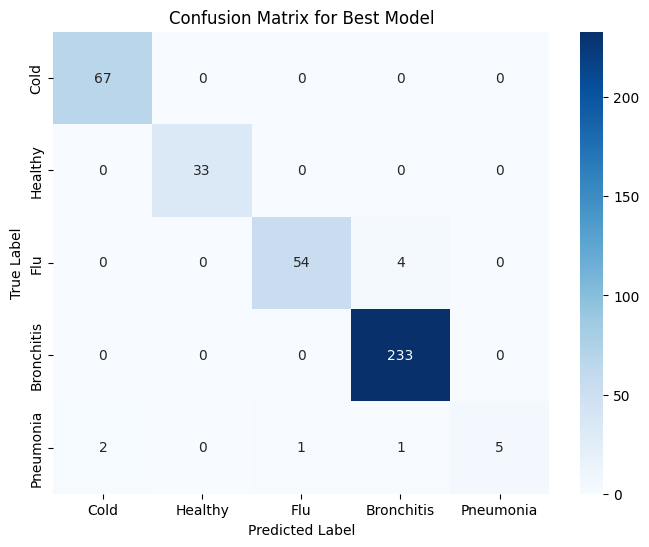

In [5]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

# --- 1. Data Loading and Feature Engineering ---
# Load the dataset
try:
    # df = pd.read_csv("disease_diagnosis.csv")
    df = pd.read_csv("../Data/disease_diagnosis.csv")
except FileNotFoundError:
    print("Error: 'disease_diagnosis.csv' not found. Please ensure it is in the same directory.")
    exit()

print("Initial Dataset Info:")
print(df.info())
print("\n" + "="*50 + "\n")

# Drop 'Patient_ID' and non-predictive output columns
df.drop(['Patient_ID', 'Severity', 'Treatment_Plan'], axis=1, inplace=True)

# Split 'Blood_Pressure_mmHg'
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood_Pressure_mmHg'].str.split('/', expand=True)
df['Systolic_BP'] = pd.to_numeric(df['Systolic_BP'])
df['Diastolic_BP'] = pd.to_numeric(df['Diastolic_BP'])
df.drop('Blood_Pressure_mmHg', axis=1, inplace=True)

# --- 2. Preprocessing & Data Splitting ---
# Define features (X) and the single target (y)
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

# Define feature types for preprocessing
numerical_features = ['Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%', 'Systolic_BP', 'Diastolic_BP']
nominal_categorical_features = ['Gender', 'Symptom_1', 'Symptom_2', 'Symptom_3']

# Create the preprocessing pipeline for features
# NOTE: SMOTE will be applied directly to the preprocessed data, so it is separate from the final pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_categorical_features)
    ],
    remainder='passthrough'
)

# Split data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape (before SMOTE): {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print("\n" + "="*50 + "\n")

# --- 3. Applying SMOTE to the Training Data ---
# Preprocess the training data first, then apply SMOTE
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print("Class distribution before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_preprocessed, y_train)

print("\nClass distribution after SMOTE:")
print(y_train_resampled.value_counts())
print("\n" + "="*50 + "\n")

# --- 4. Model Training and Evaluation ---
# Define models and their hyperparameters
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear', max_iter=1000),
}

params = {
    "Random Forest": {
        'n_estimators': [50, 100],
        'max_depth': [10, None],
        'class_weight': ['balanced', None]
    },
    "Logistic Regression": {
        'C': [0.1, 1.0],
        'class_weight': ['balanced', None]
    }
}

best_model = None
best_score = 0
model_report = {}

for name, model in models.items():
    print(f"--- Training {name} with GridSearchCV ---")
    
    # We apply GridSearchCV directly to the model and preprocessed data
    gs = GridSearchCV(model, params[name], cv=3, scoring='f1_weighted', verbose=1)
    # Fit on the SMOTE-resampled training data
    gs.fit(X_train_resampled, y_train_resampled)
    
    current_best_model = gs.best_estimator_
    
    # Predict on the original, untouched test set
    y_pred = current_best_model.predict(X_test_preprocessed)
    accuracy = accuracy_score(y_test, y_pred)
    
    model_report[name] = accuracy
    
    if accuracy > best_score:
        best_score = accuracy
        best_model = current_best_model

print("\n" + "="*50 + "\n")
print("Model Training Report:")
for name, acc in model_report.items():
    print(f"  - {name}: {acc:.4f}")

print(f"\nBest Model: {best_model.__class__.__name__} with Accuracy: {best_score:.4f}")
print("\n" + "="*50 + "\n")

# --- 5. Final Evaluation of the Best Model ---
print("Final Evaluation of the Best Model:")
y_pred = best_model.predict(X_test_preprocessed)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=y_test.unique()))

# --- 6. Visualization ---
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=y_test.unique(), yticklabels=y_test.unique())
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for Best Model')
plt.show()